In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
from types import SimpleNamespace
import matplotlib.gridspec as gridspec
import torch
import os
import matplotlib.pyplot as plt
from scipy.stats import norm
#import PCGP.gpytorch_tools as gt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import jax.numpy as jnp
import jax
import os
import numpy as np
import torch
from types import SimpleNamespace
from scipy.special import logsumexp
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

import pandas as pd
#from plot_helpers import load_run, plot_timeseries, plot_grid_posterior, plot_posterior_grid, plot_posterior_grid_3d

import seaborn as sns
plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()
save_dir = os.path.join(base_dir, "graphs")
output_data_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "output_data")
input_data_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "input_data")


In [2]:
def load_run(data_dir, fname):
    """Load a results .npz file and return its arrays as torch tensors in a namespace."""
    raw = np.load(os.path.join(data_dir, fname), allow_pickle = True)
    ns = SimpleNamespace()
    for key in raw:
        try:
            setattr(ns, key, torch.tensor(raw[key]))
        except Exception:
            setattr(ns, key, raw[key])
    return ns





_CANONICAL_ORDER = ["l_vals", "g_vals", "ls_vals", "A_vals"]


def _get_param_order(data):
    """Return the parameter axis order from data, falling back to canonical order."""
    if hasattr(data, "param_order"):
        return list(data.param_order)
    return [k for k in _CANONICAL_ORDER if hasattr(data, k)]


def _compute_marginal(mll, mode, param_order, n, marginalize_axes):
    """Marginalize a flat MLL grid: logsumexp for GT/PIGP, log-transform for Bayes.
    NaN entries (Cholesky failure for ill-conditioned params) are treated as -inf.
    The result is normalized log-probability (exp of it sums to 1 over the remaining
    grid), so panels/modes are directly comparable. Kept in log-space rather than
    exponentiated: a peaked posterior on a fine grid underflows to ~0 almost
    everywhere once exponentiated, which collapses a linear colormap to black."""
    shape = (n,) * len(param_order)
    if mode == "Bayes":
        if mll.size == n ** 3:
            print("here")
            # 3-D grid (l, g, wu): wu is also inferred, so integrate it out
            # (logsumexp over the non-plotted axes) to get the (l, g) plane
            mll_clean = np.where(np.isfinite(mll), mll, -np.inf)
            ll = logsumexp(mll_clean.reshape(shape), axis=marginalize_axes)
        else:
            # 2-D grid (l, g): nothing to marginalize, use the mll plane directly
            ll = mll.reshape(shape)
        # show the mll landscape as depth below its peak (reveals the ridges)
        log_density = -np.log(ll.max() - ll + 1)
    else:
        mll_clean = np.where(np.isfinite(mll), mll, -np.inf)
        log_density = logsumexp(mll_clean.reshape(shape), axis=marginalize_axes)
    return -np.log(log_density.max() - log_density + 1)#log_density - logsumexp(log_density)


def _get_grid_marginal(data, mode, plot_axes=None):
    """Compute the 2-D marginal posterior and its axis values for plot_axes."""
    param_order = _get_param_order(data)
    if plot_axes is None:
        plot_axes = param_order[:2]

    x_key, y_key = plot_axes
    x_ax = param_order.index(x_key)
    y_ax = param_order.index(y_key)
    marginalize_axes = tuple(i for i in range(len(param_order)) if i not in (x_ax, y_ax))

    n = len(np.asarray(getattr(data, param_order[0])))
    mll = np.asarray(data.mll_values)
    marginal = _compute_marginal(mll, mode, param_order, n, marginalize_axes)

    # after marginalization the remaining axes are in sorted (param_order) order;
    # transpose if the user wants x and y swapped relative to that
    remaining = sorted([x_ax, y_ax])
    if remaining[0] != x_ax:
        marginal = marginal.T

    x_vals = np.asarray(getattr(data, x_key))
    y_vals = np.asarray(getattr(data, y_key))
    return x_vals, y_vals, marginal


def _posterior_entropy(log_marginal):
    """Shannon entropy (nats) of a normalized log-posterior grid (exp(log_marginal)
    sums to 1). Scale-invariant: unlike the raw log-density, it only depends on the
    *shape* of the distribution, so it stays comparable across panels even when the
    absolute MLL scale differs by orders of magnitude (e.g. across sigma). Lower
    entropy = more concentrated/sharper posterior."""
    p = np.exp(log_marginal)
    contrib = p*log_marginal#np.where(p > 0, p * log_marginal, 0.0)
    return -np.sum(contrib)


def plot_grid_posterior(ax, data, mode, plot_axes=None, cmap="magenta", true_point=None,
                        vmin=None, vmax=None):
    """Plot a single posterior panel, marginalizing over all axes not in plot_axes.

    plot_axes: list of 2 key names (e.g. ["l_vals", "g_vals"]), defaults to first two
               in param_order (physical parameters). Use ["ls_vals", "A_vals"] for the
               calibration posterior.
    vmin/vmax: fix the colormap range, e.g. to share it across multiple panels.
    Returns (mesh, entropy): the QuadMesh (e.g. for a shared colorbar) and the
    posterior's entropy (scale-invariant sharpness measure, see _posterior_entropy).
    """
    x_vals, y_vals, marginal = _get_grid_marginal(data, mode, plot_axes)
    grids = np.meshgrid(x_vals, y_vals, indexing="ij")
    mesh = ax.pcolormesh(grids[0], grids[1], marginal, cmap=cmap, shading="auto",
                         vmin=vmin, vmax=vmax)
    if true_point is not None:
        ax.plot(*true_point, color="C2", marker="o", markersize=5)
    return mesh, _posterior_entropy(marginal)


def plot_posterior_grid(path, mode, sigma_list, npoints_list, possible_n,
                        plot_axes=None, cmap="magma", true_point=(2.5, 9.81)):
    """Plot a len(npoints_list) x len(sigma_list) grid of posterior panels for one mode.

    Layout: sigma runs across the top as column headers and npoints runs down the
    left as row headers (rather than repeating "n=.. noise=.." in every subplot).
    All panels share x/y axes; tick labels and axis labels (r"$\\ell$"/r"$g$") only
    appear on the bottom row / left column. Each panel keeps a small entropy
    annotation (H, scale-invariant sharpness measure, see _posterior_entropy) since
    sigma changes the absolute MLL scale by orders of magnitude, making a literal
    shared colorbar across sigma misleading.
    """
    n = possible_n[mode]
    nrows, ncols = len(npoints_list), len(sigma_list)

    panel_w, panel_h = 3.4, 3.2
    # header_w is wide enough to fit both the row-header text and the leftmost
    # panel's y-tick labels + y-label without the two colliding (both render at
    # whatever the notebook's rcParams font.size is, which can be large)
    header_w, header_h = 2.0, 0.6
    fig = plt.figure(figsize=(header_w + ncols * panel_w, header_h + nrows * panel_h))
    gs = fig.add_gridspec(nrows + 1, ncols + 1,
                          width_ratios=[header_w] + [panel_w] * ncols,
                          height_ratios=[header_h] + [panel_h] * nrows,
                          left=0.08, right=0.95, top=0.92, bottom=0.08,
                          wspace=0.08, hspace=0.08)

    vmin = vmax = None

    # column headers (sigma) and row headers (npoints), each in their own blank cell
    for j, sigma in enumerate(sigma_list):
        hax = fig.add_subplot(gs[0, j + 1])
        hax.axis("off")
        hax.text(0.5, 0.5, rf"$\sigma$ = {sigma:.2f}", ha="center", va="center")
    for i, npoints in enumerate(npoints_list):
        hax = fig.add_subplot(gs[i + 1, 0])
        hax.axis("off")
        # x=0.25: pushed toward the outer/left edge of the header column, away from
        # the main panel's y-label/tick labels that sit at the column's right edge
        hax.text(0.1, 0.5, f"n = {npoints}", ha="center", va="center", rotation=90)

    axes = np.empty((nrows, ncols), dtype=object)
    ax0, mesh = None, None
    for i, npoints in enumerate(npoints_list):
        for j, sigma in enumerate(sigma_list):
            ax = fig.add_subplot(gs[i + 1, j + 1], sharex=ax0, sharey=ax0)
            ax0 = ax0 or ax
            axes[i, j] = ax

            fname = f"{mode}_n{npoints}_sigma{sigma:.2f}_fulln{n}.npz"
            data = load_run(path, fname)
            mesh, entropy = plot_grid_posterior(ax, data, mode, plot_axes, cmap,
                                                true_point, vmin=vmin, vmax=vmax)
            #ax.text(0.96, 0.94, f"H={abs(entropy):.2f}", transform=ax.transAxes,
            #        ha="right", va="top", color="white", fontsize = 18,
            #        bbox=dict(boxstyle="round", fc="black", alpha=0.45, pad=0.25))

            ax.tick_params(labelbottom=(i == nrows - 1), labelleft=(j == 0))
            if i == nrows - 1:
                ax.set_xlabel(r"$\ell$")
            if j == 0:
                ax.set_ylabel(r"$g$")

    fig.suptitle(mode, fontsize = 28)
    return fig, axes





I tested "hyperhyperparameters" a) shared kernel vs no shared kernel and b) amplitude and lengthscale optimized or fixed. Results did not vary drastically so I will show results for the combination "shared kernel" and "calibration parameters optimized". I will show: a) original style MAE plot to compare if the result has gotten worse, b) all Posterior plots in one image for PIGP and GT c) an example of what i think is going wrong now compared to the earlier version d) a boxplot style MAE plot but for the old data since that's a statistical tool
extra sigmaGT 
theory: improving boxplot result
Praxis: nein tut's nicht.
Erklärung: vermutlich ill conditioned -> unstable

# Real experiment metrics

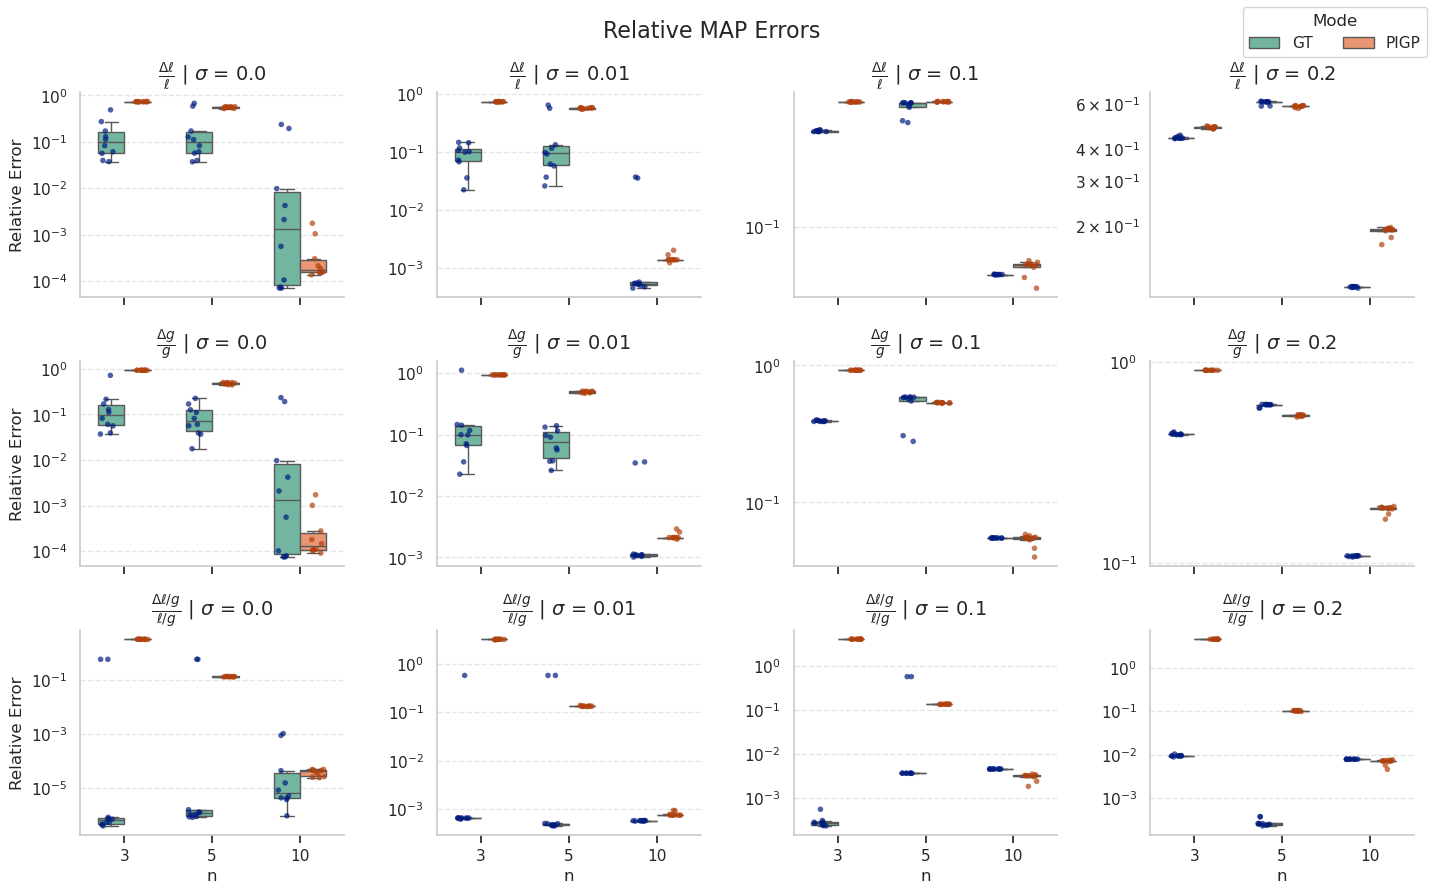

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
runs = 10

sigma_list = [0.0, 0.01, 0.1, 0.2]
n_list = [3, 5, 10]
modes = ["GT", "PIGP"]

data_mode = ["extra_npoints_extra_sigma", "standard"]
param_names = [r'$\frac{\Delta \ell}{\ell}$', r'$\frac{\Delta g}{g}$', r'$\frac{\Delta \ell/g}{\ell/g}$']



#load data
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 3, runs))

for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            path = os.path.join(output_data_ex2, data_mode[j])
            for run in range(runs):
                fname = f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"
                d = load_run(path, fname)
                #print(d.true_parameters)
                all_AE[n_idx, sigma_idx, j, 0, run] = abs((d.learned_parameters[0] - d.true_parameters[0])/d.true_parameters[0])
                all_AE[n_idx, sigma_idx, j, 1, run] = abs((d.learned_parameters[1] - d.true_parameters[1])/d.true_parameters[1])
                all_AE[n_idx, sigma_idx, j, 2, run] = abs((d.learned_parameters[0] / d.learned_parameters[1]- d.true_parameters[0] / d.true_parameters[1])/(d.true_parameters[0] / d.true_parameters[1]))
               

#reshape
records = []
for n_idx, n in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for mode_idx, mode in enumerate(modes):
            for param_idx, param in enumerate(param_names):
                for run in range(runs):
                    records.append({
                        "n": n,
                        "sigma": sigma,
                        "mode": mode,
                        "param": param,
                        "AE": all_AE[n_idx, sigma_idx, mode_idx, param_idx, run]})

df = pd.DataFrame.from_records(records)

# categorical ordering 
df["n"] = pd.Categorical(df["n"], categories=n_list, ordered=True)
df["sigma"] = pd.Categorical(df["sigma"], categories=sigma_list, ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=modes, ordered=True)
df["param"] = pd.Categorical(df["param"], categories=param_names, ordered=True)
sns.set(style="whitegrid")

g = sns.FacetGrid(
    df,
    row="param",
    col="sigma",
    height=3,
    aspect=1.2,
    sharey=False,
    margin_titles=False
)

def box_and_points(data, **kwargs):

    ax = plt.gca()

    # boxplots
    sns.boxplot(
        data=data,
        x="n",
        y="AE",
        hue="mode",
        dodge=True,
        width=0.6,
        showfliers=False,
        palette="Set2",
        ax=ax
    )

    # individual runs
    sns.stripplot(
        data=data,
        x="n",
        y="AE",
        hue="mode",
        dodge=True,
        jitter=0.15,
        size=4,
        alpha=0.7,
        palette="dark",
        ax=ax
    )

    # remove duplicate legends created by both plots
    if ax.legend_ is not None:
        ax.legend_.remove()

g.map_dataframe(box_and_points)

# single legend
handles, labels = g.axes[0,0].get_legend_handles_labels()
g.figure.legend(
    handles[:2],
    labels[:2],
    title="Mode",
   # loc="upper center",
    ncol=2
)

# formatting: put "param | sigma = ..." in each subplot title (no right-side row labels)
nrows, ncols = g.axes.shape
for i in range(nrows):
    for j in range(ncols):
        ax = g.axes[i, j]
        ax.set_yscale("log")
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax.set_title(rf"{g.row_names[i]} | $\sigma$ = {g.col_names[j]}", fontsize=14)
        # keep x-axis ticks on every panel, but tick labels only on the bottom row
        ax.tick_params(axis="x", which="both", bottom=True,
                       labelbottom=(i == nrows - 1))

g.set_axis_labels("n", "Relative Error")

g.figure.suptitle(
    f"Relative MAP Errors",
    fontsize=16
)

g.figure.tight_layout()
g.figure.subplots_adjust(top=0.90)

plt.savefig(os.path.join(save_dir, "Ex2_inverse.pdf"),bbox_inches='tight' )

# grid based posteriors

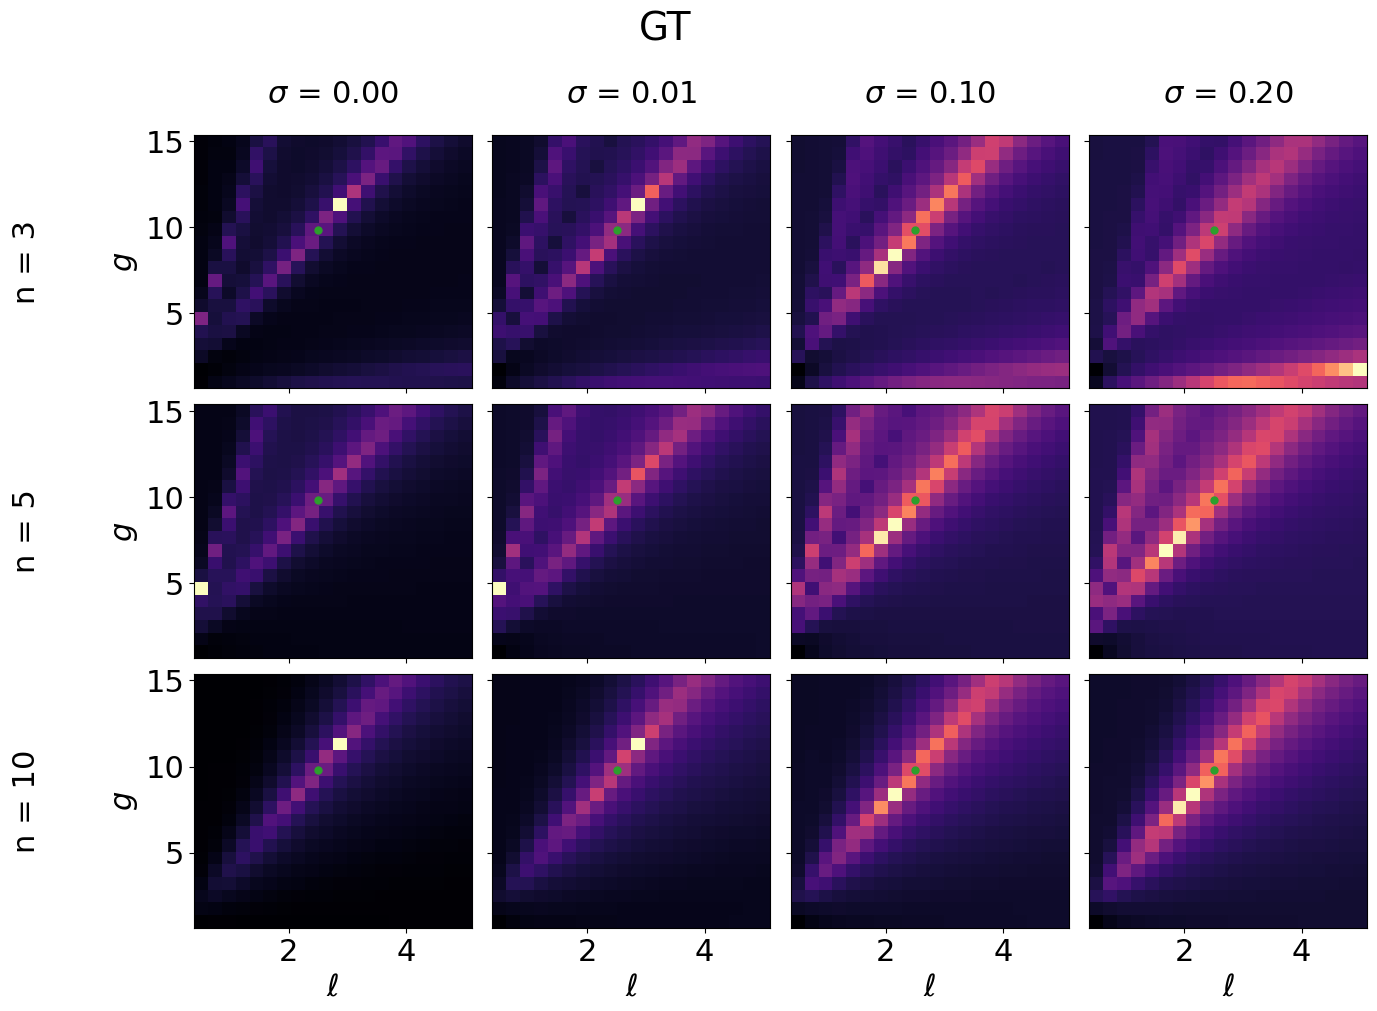

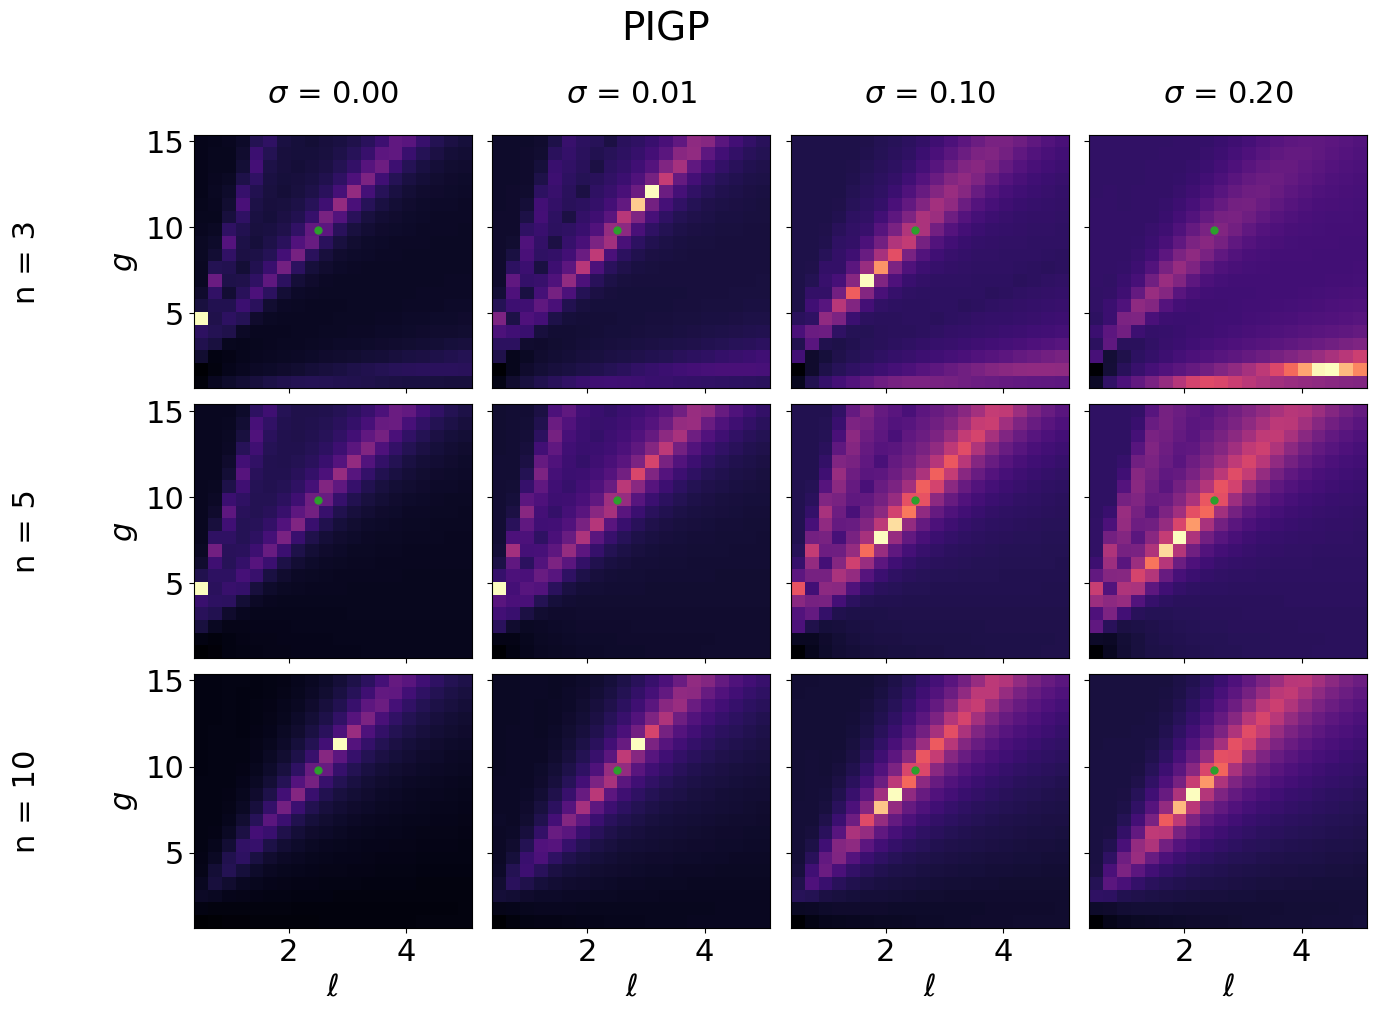

In [4]:
data_mode = "standard"
grid_path1  = os.path.join(base_dir, "Experiment2_Tripendulum", "grid_evaluation", "output", "known_u_known_sigma")
grid_path2  = os.path.join(base_dir, "Experiment2_Tripendulum", "grid_evaluation", "output",  "known_u_known_sigma")

sigma_list    = [0.0, 0.01, 0.1, 0.2]
npoints_list  = [3, 5, 10]
possible_n    = {"GT": 20, "PIGP": 20, "Bayes": 50}

#fig, axes = plot_posterior_grid(grid_path2, "Bayes", sigma_list, npoints_list, possible_n, cmap = "magma")
#plt.savefig(os.path.join(save_dir, "Ex2_posterior_Bayes.pdf"),bbox_inches='tight' )
fig, axes = plot_posterior_grid(grid_path1, "GT", sigma_list, npoints_list, possible_n, cmap = "magma")
plt.savefig(os.path.join(save_dir, "Ex2_posterior_GT_knownu.pdf"),bbox_inches='tight' )
fig, axes = plot_posterior_grid(grid_path1, "PIGP", sigma_list, npoints_list, possible_n, cmap = "magma")
plt.savefig(os.path.join(save_dir, "Ex2_posterior_PIGP_knownu.pdf"),bbox_inches='tight' )

#plt.savefig(f"Ex2_grid_Bayes.pdf")
#fig, axes = plot_posterior_grid(grid_path, "PIGP", sigma_list, npoints_list, possible_n, cmap = "magma")
#plt.savefig(f"Ex2_grid_{data_mode}_PIGP.pdf")

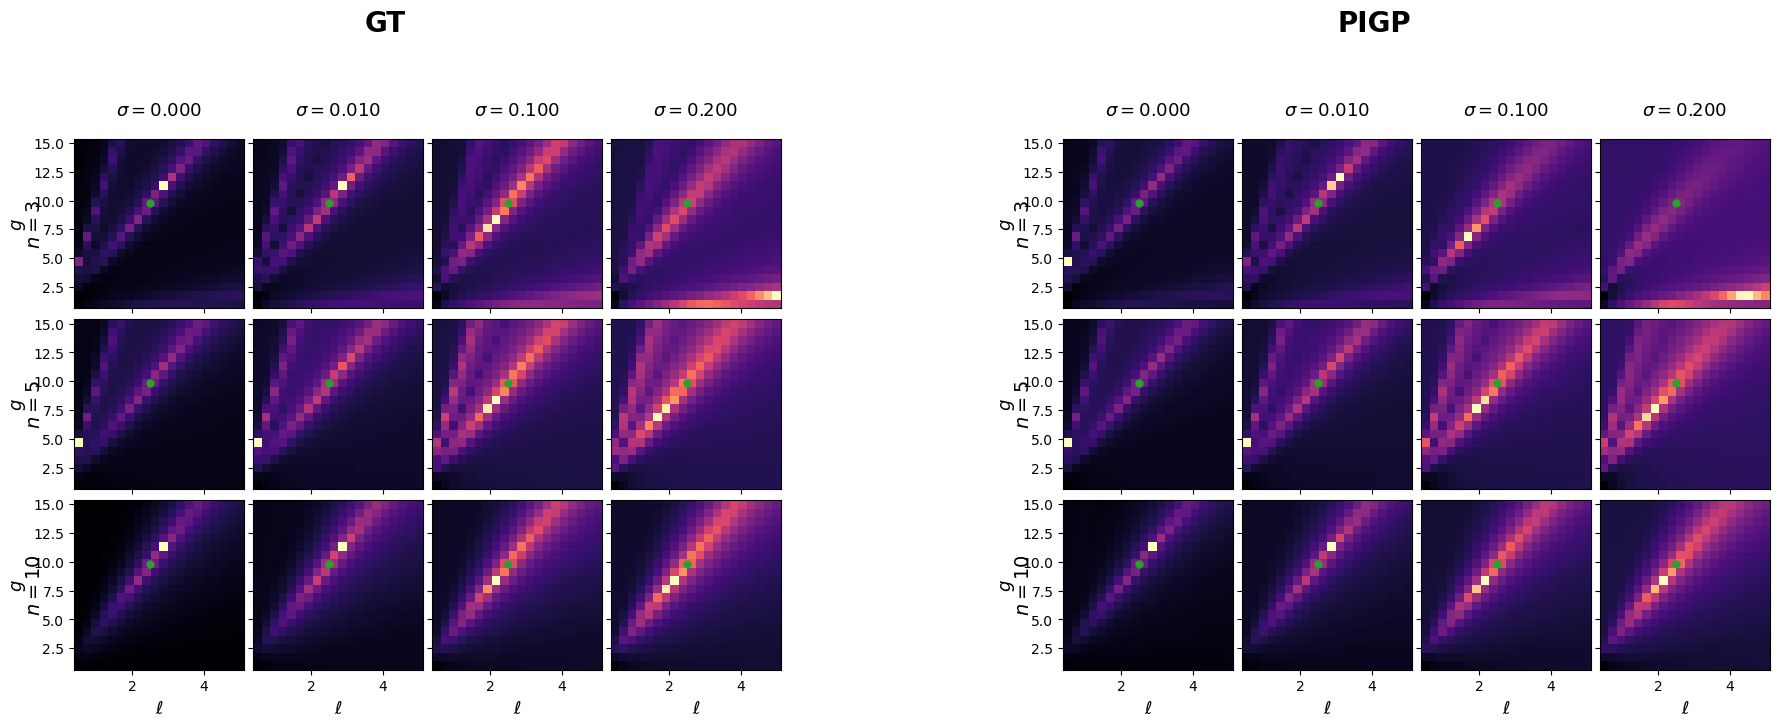

In [16]:
# ── GT vs PIGP posterior grids, side by side ──────────────────────────────────
# smallest order of magnitude a float can hold; entropies below it have underflowed
# to ~0 (near-delta posterior) and are shown as "H < 1e-308" instead of "0.0e+00".
H_FLOOR_EXP = 1e-12#int(np.floor(np.log10(np.finfo(float).tiny)))


def _entropy_label(entropy):
    """Entropy inset text: scientific notation with 1 digit, or a floor label when
    the value has underflowed to (essentially) zero."""
    h = abs(entropy)
    if h < 10.0 ** H_FLOOR_EXP:
        return rf"$H<1e{H_FLOOR_EXP}$"
    return rf"$H={h:.1e}$"


def _robust_vmin(marginal, clip_pct):
    """Lower colour limit at the clip_pct-th percentile of the (l, g) log-marginal.
    A few extreme-negative cells otherwise stretch the auto range so far that all
    the real structure collapses into the top sliver of the colormap (uniform
    yellow at low n / low sigma); clipping the bottom clip_pct% restores contrast.
    Set clip_pct=None for raw auto-scaling."""
    if clip_pct is None:
        return None
    finite = np.where(np.isfinite(marginal), marginal, np.nan)
    return float(np.nanpercentile(finite, clip_pct))


def _draw_method_grid(subfig, path, mode, sigma_list, npoints_list, n,
                      plot_axes=None, cmap="magma", true_point=(2.5, 9.81), clip_pct=25):
    """Draw one method's (npoints x sigma) array of (l, g) posterior panels into
    `subfig`. Rows are labelled by n, columns by sigma, and each panel shows its
    entropy H as an inset (smaller H = sharper posterior). Each panel is contrast-
    clipped at the clip_pct-th percentile of its marginal (clip_pct=None disables)."""
    nrows, ncols = len(npoints_list), len(sigma_list)
    gs = subfig.add_gridspec(nrows + 1, ncols + 1,
                             width_ratios=[0.3] + [1] * ncols,
                             height_ratios=[0.25] + [1] * nrows,
                             wspace=0.06, hspace=0.08)

    # column headers (sigma) along the top, row headers (n) down the left
    for j, sigma in enumerate(sigma_list):
        hax = subfig.add_subplot(gs[0, j + 1]); hax.axis("off")
        hax.text(0.5, 0.4, rf"$\sigma={sigma:.3f}$", ha="center", va="center", fontsize=13)
    for i, npoints in enumerate(npoints_list):
        hax = subfig.add_subplot(gs[i + 1, 0]); hax.axis("off")
        hax.text(0.4, 0.5, rf"$n={npoints}$", ha="center", va="center",
                 rotation=90, fontsize=14)

    shared = None
    for i, npoints in enumerate(npoints_list):
        for j, sigma in enumerate(sigma_list):
            ax = subfig.add_subplot(gs[i + 1, j + 1], sharex=shared, sharey=shared)
            shared = shared or ax

            data = load_run(path, f"{mode}_n{npoints}_sigma{sigma:.2f}_fulln{n}.npz")
            # robust per-panel contrast: clip vmin at a percentile of the marginal
            _, _, marginal = _get_grid_marginal(data, mode, plot_axes)
            vmin = _robust_vmin(marginal, clip_pct)
            _, entropy = plot_grid_posterior(ax, data, mode, plot_axes, cmap,
                                             true_point)#, vmin=vmin)

            # entropy inset: scientific notation, 1 digit (floored when ~0)
            #ax.text(0.95, 0.95, _entropy_label(entropy), transform=ax.transAxes,
            #        ha="right", va="top", fontsize=11, color="white",
            #        bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6))

            ax.tick_params(labelbottom=(i == nrows - 1), labelleft=(j == 0), labelsize=10)
            if i == nrows - 1:
                ax.set_xlabel(r"$\ell$", fontsize=13)
            if j == 0:
                ax.set_ylabel(r"$g$", fontsize=13)

    subfig.suptitle(mode, fontsize=20, fontweight="bold")


def plot_gt_pigp_grids(grid_path, data_mode, sigma_list, npoints_list, possible_n,
                       plot_axes=None, cmap="magma", true_point=(2.5, 9.81), clip_pct=25):
    """Full GT grid (left) and PIGP grid (right) in a single figure, both read from
    <grid_path>/<data_mode>/."""
    nrows, ncols = len(npoints_list), len(sigma_list)
    panel = 2.3
    fig = plt.figure(figsize=(2 * (0.3 + ncols) * panel , (0.3 + nrows) * panel))
    left, right = fig.subfigures(1, 2, wspace=0)

    path = os.path.join(grid_path, data_mode)
    for subfig, mode in ((left, "GT"), (right, "PIGP")):
        _draw_method_grid(subfig, path, mode, sigma_list, npoints_list,
                          possible_n[mode], plot_axes, cmap, true_point, clip_pct)
    return fig


grid_path    = os.path.join(base_dir, "Experiment2_Tripendulum", "grid_evaluation", "output")
data_mode    = "known_u_known_sigma"#"extra_npoints_extra_sigma"
sigma_list   = [0.0, 0.01, 0.1, 0.2]
npoints_list = [3, 5, 10]
possible_n   = {"GT": 20, "PIGP": 20}

fig = plot_gt_pigp_grids(grid_path, data_mode, sigma_list, npoints_list, possible_n,
                         clip_pct=25)
#plt.savefig(os.path.join(save_dir, f"Ex2_grids_knownu.pdf"), bbox_inches="tight")


In [6]:
def plot_methods_comparison(grid_path, npoints, sigma, data_mode="standard",
                            possible_n=None, modes=("Bayes", "GT", "PIGP"),
                            plot_axes=None, cmap="magma", true_point=(2.5, 9.81),
                            colorbar=True, share_scale=False):
    """Plot the (l, g) grid posterior for several methods side-by-side, for one
    (npoints, sigma) setting. Reuses load_run / plot_grid_posterior, so the
    marginalization is identical to plot_posterior_grid: Bayes is read straight
    from grid_path, GT/PIGP from grid_path/<data_mode>, and the calibration axes
    (ls, A) are marginalized out (logsumexp) for GT/PIGP.

    modes:        which methods to show, one column each.
    plot_axes:    pair of keys to plot, default ["l_vals", "g_vals"].
    share_scale:  if True all panels share one vmin/vmax + a single colorbar;
                  default False since the normalized log-marginals differ in
                  absolute level across methods (Bayes uses -log|mll|).
    Returns (fig, axes)."""
    if possible_n is None:
        possible_n = {"GT": 20, "PIGP": 20, "Bayes": 50}
    x_key, y_key = plot_axes if plot_axes is not None else ["l_vals", "g_vals"]

    def _source(mode):
        d = grid_path if mode == "Bayes" else os.path.join(grid_path, data_mode)
        fname = f"{mode}_n{npoints}_sigma{sigma:.2f}_fulln{possible_n[mode]}.npz"
        return load_run(d, fname)

    datas = {m: _source(m) for m in modes}

    vmin = vmax = None
    if share_scale:
        marg = [_get_grid_marginal(datas[m], m, [x_key, y_key])[2] for m in modes]
        vmin = min(np.nanmin(mm) for mm in marg)
        vmax = max(np.nanmax(mm) for mm in marg)

    fig, axes = plt.subplots(1, len(modes), figsize=(4.4 * len(modes), 4.0),
                             sharex=True, sharey=True, squeeze=False)
    axes = axes[0]

    mesh = None
    for ax, mode in zip(axes, modes):
        mesh, entropy = plot_grid_posterior(ax, datas[mode], mode, [x_key, y_key],
                                            cmap, true_point, vmin=vmin, vmax=vmax)
        ax.set_title(f"{mode}  (H={abs(entropy):.2f})")
        ax.set_xlabel(r"$\ell$")
        if colorbar and not share_scale:
            fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)

    axes[0].set_ylabel(r"$g$")
    if colorbar and share_scale and mesh is not None:
        fig.colorbar(mesh, ax=list(axes), fraction=0.046, pad=0.04)
    fig.suptitle(rf"n = {npoints},  $\sigma$ = {sigma:.2f}", fontsize=24)
    if not share_scale:
        fig.tight_layout()
    return fig, axes


# Bayes vs GT vs PIGP for one (n, sigma)
fig, axes = plot_methods_comparison(grid_path, npoints=10, sigma=0.1,
                                    data_mode=data_mode, possible_n=None,
                                    cmap="magma")
#plt.savefig(os.path.join(save_dir, f"Ex2_grid_compare_{data_mode}_n10_sigma0.10.pdf"),
#            bbox_inches="tight")


KeyError: 'Bayes'

In [18]:
def plot_timeseries(fig, data, num_tasks, task_labels, outer_spec=None, title="Forward fit",
                    grid_rows=None, xlim=None):
    """Plot stacked per-task time series into outer_spec, or the full figure if None.

    grid_rows: total rows of the inner grid (default num_tasks). If larger, the
               extra (empty) rows sit at the BOTTOM, so every panel keeps exactly
               the same height as a taller neighbouring column.
    xlim:      shared (xmin, xmax) so the t-axis matches across columns.
    NOTE: for exactly equal-sized panels, use a figure WITHOUT constrained_layout
    (constrained_layout shrinks panels that carry a title / xlabel).
    """
    from matplotlib.ticker import MaxNLocator
    rows = grid_rows or num_tasks
    if outer_spec is None:
        inner = gridspec.GridSpec(rows, 1, figure=fig, hspace=0.05)
    else:
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, 1, subplot_spec=outer_spec, hspace=0.05
        )
    first_ax = None
    for i in range(num_tasks):                 # rows 0..num_tasks-1; blank rows at bottom
        mask_test  = data.test_x[..., -1] == i
        mask_train = data.train_x[..., -1] == i
        t_test  = data.test_x[mask_test, 0]
        t_train = data.train_x[mask_train, 0]

        ax = fig.add_subplot(inner[i, 0], sharex=first_ax)
        ax.grid(False)
        first_ax = first_ax or ax
        ax.plot(t_test, data.mean[mask_test], "b", linewidth=2)
        ax.fill_between(t_test, data.lower[mask_test], data.upper[mask_test], alpha=0.3)
        ax.plot(t_test, data.test_y[mask_test], "r--")
        ax.plot(t_train, data.train_y[mask_train], "k*")
        ax.set_ylabel(task_labels[i], fontsize=22)
        # prune the top/bottom y-tick labels so they don't collide with the
        # neighbouring stacked panel's boundary ticks (hspace is tiny)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3, prune="both"))
        if xlim is not None:
            ax.set_xlim(xlim)

        # per-task RMSE annotation (like the forward problem in Ex1_metrics)
        err = data.mean[mask_test] - data.test_y[mask_test]
        rmse = float(np.sqrt((np.asarray(err) ** 2).mean()))
        ax.text(0.97, 0.94, f"RMSE={rmse:.4f}", transform=ax.transAxes,
                ha="right", va="top", fontsize=14, color="white",
                bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.55))

        if i < num_tasks - 1:
            ax.tick_params(labelbottom=False, bottom=False, labelsize=18)
        else:
            ax.set_xlabel(r"$t$", fontsize=22)
            ax.tick_params(labelsize=18)

        if i == 0:
            ax.set_title(title, fontsize=24)

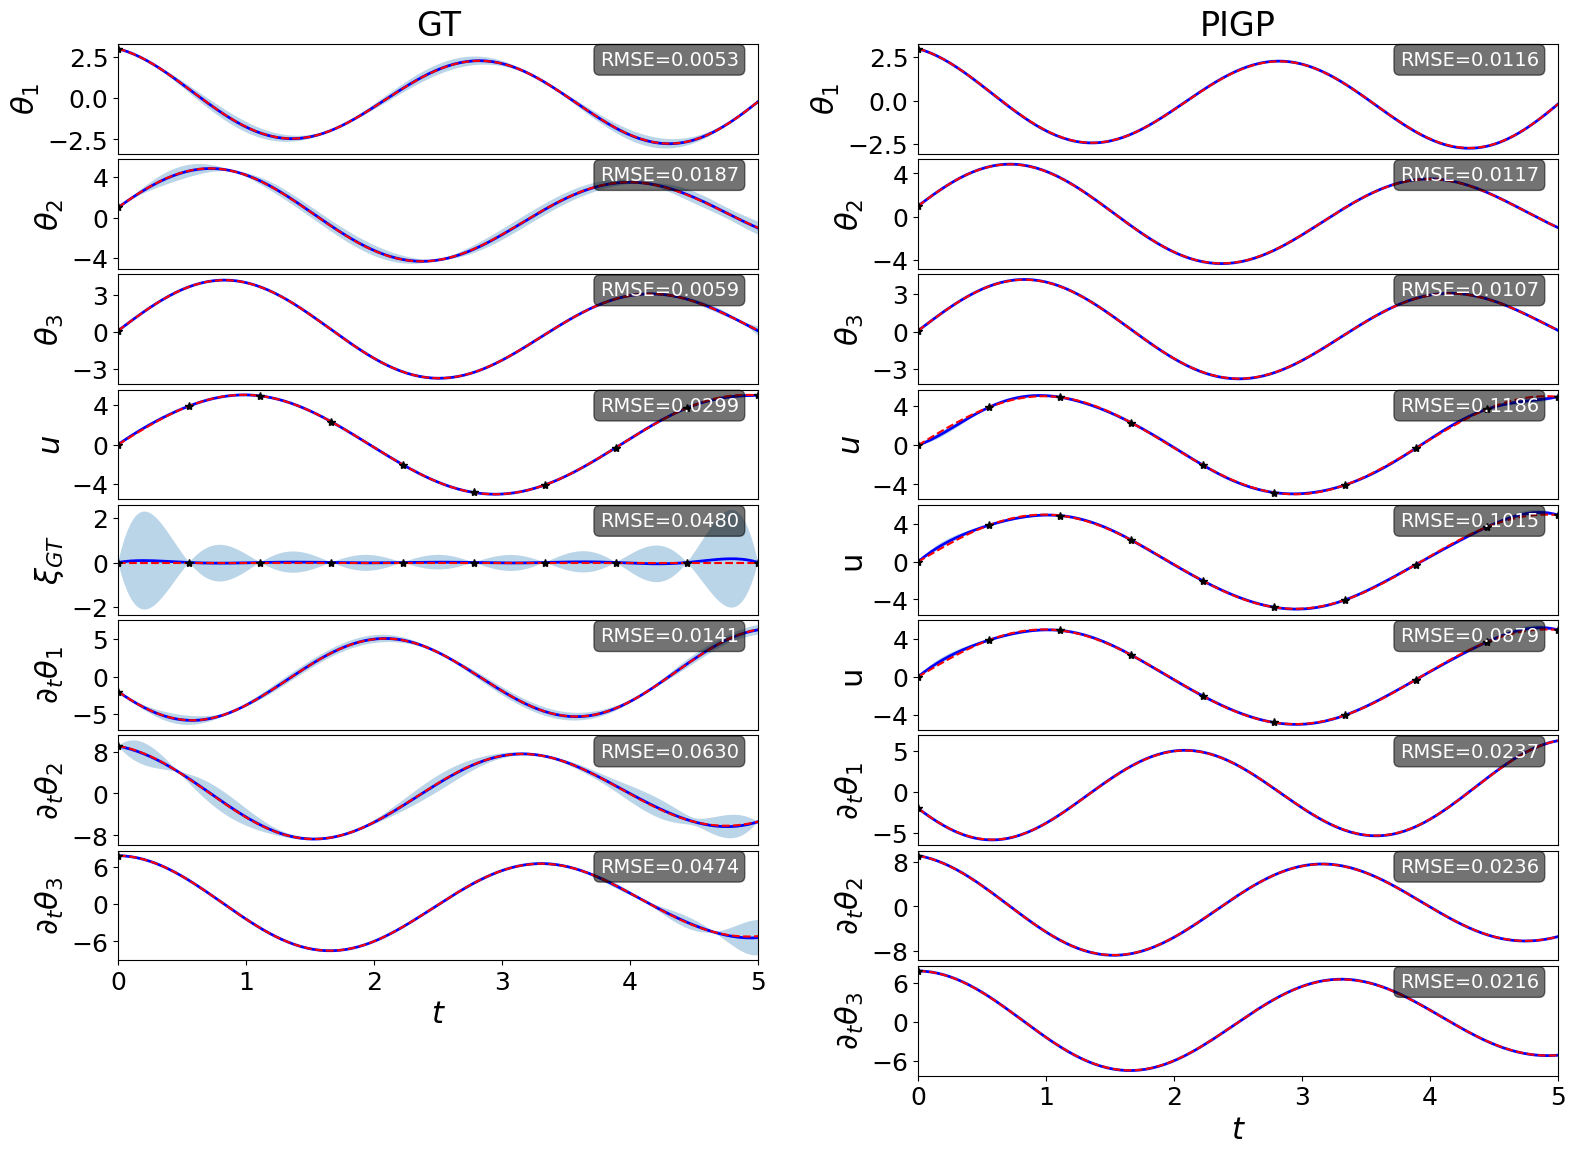

In [21]:
# GT and PIGP forward fits side by side (aligned time axis, equal-sized panels)
num_tasks = {"GT": 8, "PIGP": 9}
task_labels = {"GT":  [r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$u$", r"$\xi_{GT}$", r"$\partial_t\theta_1$", r"$\partial_t\theta_2$", r"$\partial_t\theta_3$"],
               "PIGP": [r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$u$", r"u", r"u", r"$\partial_t\theta_1$", r"$\partial_t\theta_2$", r"$\partial_t\theta_3$"]}

data_dir = os.path.join(output_data_ex2, "forward")
datas = {mode: load_run(data_dir, f"Ex2_{mode}.npz") for mode in ["GT", "PIGP"]}

grid_rows = max(num_tasks.values())                      # both columns use the same #rows
tcat = np.concatenate([np.asarray(d.test_x[:, 0]) for d in datas.values()])
xlim = (float(tcat.min()), float(tcat.max()))            # shared t-axis across columns

# no constrained_layout: a plain fixed-margin gridspec keeps every cell exactly equal
fig = plt.figure(figsize=(16, 12))
outer = fig.add_gridspec(1, 2, left=0.07, right=0.97, top=0.93, bottom=0.07, wspace=0.25)

for col, mode in enumerate(["GT", "PIGP"]):
    plot_timeseries(fig, datas[mode], num_tasks=num_tasks[mode],
                    task_labels=task_labels[mode], outer_spec=outer[0, col],
                    title=mode, grid_rows=grid_rows, xlim=xlim)

plt.savefig(os.path.join(save_dir, "Ex2_forward.pdf"), bbox_inches="tight")